# NLP Workflow - Empirical evaluation of optimum k (number of topics) for LDA

## This Notebook Covers
**Objective:** Empirically determine optimal LDA configuration for 1.4M CFPB complaints

**Tests:**
1. **Optimal topic count** - Test k = {20, 30, 50, 75, 100}
2. **Unigram vs Bigram** - Using optimal k from step 1
3. **Vocabulary strategy** - Keep legal codes vs remove them

## Libraries Used
- **Python:** pandas, sklearn, matplotlib

---
## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import time
import pickle
import json
from tqdm import tqdm
import multiprocessing as mp
from multiprocessing import Pool

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split

# Visualization
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

---
## 2. Load Full Dataset

In [3]:
print("=" * 70)
print("LOADING FULL DATASET")
print("=" * 70)

# Load the full NLP features dataset
df = pd.read_csv('data/complaints_with_nlp_features_deep_clean.csv',
                 engine='python',
                 on_bad_lines='skip')

print(f"\nLoaded {len(df):,} complaints")
print(f"   Columns: {len(df.columns)}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Check for cleaned text column
if 'narrative_clean' in df.columns:
    text_col = 'narrative_clean'
elif 'narrative_cleaned' in df.columns:
    text_col = 'narrative_cleaned'
else:
    raise ValueError("No cleaned narrative column found!")

print(f"\n   Using text column: '{text_col}'")

# Filter to non-null text
df_text = df[df[text_col].notna()].copy()
print(f"   With text: {len(df_text):,} complaints")

df_text.head(3)

LOADING FULL DATASET

Loaded 1,400,010 complaints
   Columns: 30
   Memory: 6239.7 MB

   Using text column: 'narrative_clean'
   With text: 1,400,010 complaints


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,narrative_cleaned
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,writing following information removed credit f...
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,victim identity theft please delete remove ite...
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140,name formally disputing fraudulent auto loan s...


---
## 3. Text Cleaning (Keeping Legal Codes)

**Philosophy:** Legal codes like "15usc1681" (FCRA) are MEANINGFUL features!
- They indicate which law the consumer is citing
- Different laws = different complaint types

**Removal:**
- XXXX redaction patterns
- Standalone numbers (but keep alphanumeric codes)
- Very short tokens (1-2 chars)

In [5]:
def clean_for_lda(text):
    """
    Remove:
    - XXXX redaction patterns
    - Standalone pure numbers
    - Very short tokens
    
    Keep:
    - Legal codes: 15usc1681, 12cfr1005, etc.
    - Alphanumeric terms with meaning
    """
    if not text or pd.isna(text):
        return ""
    
    # Remove XXXX redaction patterns
    text = re.sub(r'\b[xX]{2,}\b', '', text)
    
    # Remove standalone pure numbers
    text = re.sub(r'\b\d+\s', ' ', text)  
    text = re.sub(r'\s\d+\b', ' ', text)  
    
    # Remove very short tokens (but after number removal)
    text = re.sub(r'\b\w{1,2}\b', '', text)
    
    # Clean whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

start = time.time()

df_text['narrative_for_lda'] = df_text[text_col].map(clean_for_lda)

clean_time = time.time() - start

print(f"\nCleaning complete: {clean_time:.1f}s")
print(f"   Speed: {len(df_text)/clean_time:,.0f} complaints/second")

# Remove empty texts
df_lda = df_text[df_text['narrative_for_lda'].str.len() > 20].copy()
print(f"\n   Kept {len(df_lda):,} complaints (removed {len(df_text) - len(df_lda):,} too short)")

print(f"\nExample cleaned text:")
print(f"   {df_lda['narrative_for_lda'].iloc[0][:200]}...")


Cleaning complete: 238.7s
   Speed: 5,864 complaints/second

   Kept 1,399,222 complaints (removed 788 too short)

Example cleaned text:
   writing have the following information removed from credit file, the items that need deleted are going attached word document. victim identity theft. have multiple accounts and inquiries that did not ...


In [6]:
df_lda.to_csv('data/complaints_with_nlp_features_lda.csv', index=False)

---
## 4. Train-Test Split

In [2]:
df_lda = pd.read_csv('data/complaints_with_nlp_features_lda.csv',
                 engine='python',
                 on_bad_lines='skip')

In [9]:
SAMPLE_SIZE = 100000

sample_df = df_lda.sample(n=SAMPLE_SIZE, random_state=42)

In [10]:
sample_df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,narrative_cleaned,narrative_for_lda
558178,10/23/25,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,THESE ACCOUNTS DO NOT BELONG TO ME AND ARE NEG...,NaN,"EQUIFAX, INC.",NJ,07013,NaN,Consent provided,Web,10/24/25,Closed with explanation,Yes,NaN,16771326,these accounts do not belong to me and are neg...,accounts not belong negatively impacting credi...,0.7579,0.000,0.819,0.181,0.0,0.0,0.2,215,37,accounts not belong negatively impacting credi...,these accounts not belong and are negatively i...
1314507,09/18/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,The fair resolution is the permanent deletion ...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",PA,19139,NaN,Consent provided,Web,09/18/25,Closed with non-monetary relief,Yes,NaN,16028369,the fair resolution is the permanent deletion ...,fair resolution permanent deletion inaccurate ...,0.4019,0.040,0.871,0.089,0.0,0.0,0.0,337,51,fair resolution permanent deletion inaccurate ...,the fair resolution the permanent deletion all...
995438,03/14/23,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,I reviewed my Consumer Reports and noticed tha...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,TX,75227,NaN,Consent provided,Web,03/14/23,Closed with explanation,Yes,NaN,6694943,i reviewed my consumer reports and noticed tha...,reviewed consumer reports noticed two late pay...,0.7960,0.034,0.869,0.097,0.0,0.0,0.0,575,105,reviewed consumer reports noticed two late pay...,reviewed consumer reports and noticed that had...
256977,01/26/24,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I'm submitting a complaint to you today to inf...,NaN,"EQUIFAX, INC.",NC,284XX,NaN,Consent provided,Web,01/26/24,Closed with explanation,Yes,NaN,8229068,i'm submitting a complaint to you today to inf...,'m submitting complaint today inform victim id...,-0.8807,0.086,0.879,0.035,1.0,0.0,0.0,1173,200,' submitting complaint today inform victim ide...,' submitting complaint you today inform you th...
44735,03/11/25,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,"Inaccurate charge offs, accounts closed, old a...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",VA,24112,NaN,Consent provided,Web,03/11/25,Closed with explanation,Yes,NaN,12416821,"inaccurate charge offs, accounts closed, old a...",inaccurate charge offs accounts closed old add...,0.0000,0.000,1.000,0.000,0.0,0.4,0.0,54,7,inaccurate charge offs accounts closed old add...,"inaccurate charge offs, accounts closed, old a..."


In [15]:
print("=" * 70)
print("TRAIN/TEST SPLIT FOR PERPLEXITY")
print("=" * 70)

print(f"\nFull dataset: {len(df_lda):,} complaints")
print(f"Split: 80% train, 20% test")
print(f"Random seed: 42")

train_texts, test_texts = train_test_split(
    df_lda['narrative_for_lda'],
    test_size=0.2,
    random_state=42
)

print(f"\nSplit complete:")
print(f"   Train: {len(train_texts):,} complaints")
print(f"   Test:  {len(test_texts):,} complaints")

TRAIN/TEST SPLIT FOR PERPLEXITY

Full dataset: 1,399,222 complaints
Split: 80% train, 20% test
Random seed: 42

Split complete:
   Train: 1,119,377 complaints
   Test:  279,845 complaints


---
## 5. Build Vocabulary (Large, Includes Legal Codes)

**For 1.4M documents:**
- Vocabulary size: 50,000 (much larger than 5K used for 30K sample)
- Allows alphanumeric tokens (legal codes)
- Higher min_df to filter typos

In [16]:
print("=" * 70)
print("BUILDING VOCABULARY")
print("=" * 70)

print("\nConfiguration:")
print(f"   max_features: 50,000")
print(f"   min_df: 20 (must appear in ≥20 docs)")
print(f"   max_df: 0.5 (remove words in >50% docs)")
print(f"   token_pattern: alphanumeric")

vectorizer_base = CountVectorizer(
    max_features=50000,
    min_df=20,
    max_df=0.5,
    ngram_range=(1, 1),
    token_pattern=r'(?u)\b\w+\b', 
    stop_words='english'
)

print("\nFitting vocabulary on training data...")
start = time.time()
train_bow = vectorizer_base.fit_transform(train_texts)
vocab_time = time.time() - start

vocab = vectorizer_base.get_feature_names_out()

print(f"\nVocabulary built: {vocab_time:.1f}s")
print(f"   Total terms: {len(vocab):,}")
print(f"   Matrix shape: {train_bow.shape}")
print(f"   Sparsity: {(1 - train_bow.nnz / (train_bow.shape[0] * train_bow.shape[1]))*100:.2f}%")

# Analyze vocabulary composition
pure_words = [w for w in vocab if w.isalpha() and len(w) > 2]
legal_codes = [w for w in vocab if re.search(r'\d', w) and re.search(r'[a-zA-Z]', w)]
pure_numbers = [w for w in vocab if w.isdigit()]

print(f"\nVocabulary composition:")
print(f"   Pure words: {len(pure_words):,} ({len(pure_words)/len(vocab)*100:.1f}%)")
print(f"   Legal codes: {len(legal_codes):,} ({len(legal_codes)/len(vocab)*100:.1f}%)")
print(f"   Pure numbers: {len(pure_numbers):,} ({len(pure_numbers)/len(vocab)*100:.1f}%)")

print(f"\nExample legal codes in vocabulary:")
print(f"   {legal_codes[:20]}")

print(f"\nFirst 30 pure words:")
print(f"   {pure_words[:30]}")

BUILDING VOCABULARY

Configuration:
   max_features: 50,000
   min_df: 20 (must appear in ≥20 docs)
   max_df: 0.5 (remove words in >50% docs)
   token_pattern: alphanumeric

Fitting vocabulary on training data...

Vocabulary built: 74.9s
   Total terms: 16,850
   Matrix shape: (1119377, 16850)
   Sparsity: 99.72%

Vocabulary composition:
   Pure words: 16,409 (97.4%)
   Legal codes: 330 (2.0%)
   Pure numbers: 72 (0.4%)

Example legal codes in vocabulary:
   ['100s', '1028a', '1087e', '1098s', '1099a', '1099b', '1099c', '1099s', '10b', '10days', '10th', '10x', '11681x', '11b', '11th', '120days', '1232g', '12cfr', '12th', '12u']

First 30 pure words:
   ['aaa', 'aaccordance', 'aadvantage', 'aafes', 'aargon', 'aba', 'aback', 'abandon', 'abandoned', 'abandoning', 'abandonment', 'abandonments', 'abatement', 'abbreviated', 'abbreviation', 'abbreviations', 'abd', 'abet', 'abetted', 'abetting', 'abhorrent', 'abide', 'abided', 'abiding', 'abilities', 'ability', 'able', 'abnormal', 'abode', 'a

---
## 6. Finding Optimal Number of Topics

**Research Question:** What's the optimum number of topics for 1.4M documents?

**Hypothesis:** 5 topics (from small sample) is few for 1.4M docs, so testing optimum number of topics on sample dataset

**Test:** Evaluate k ∈ {5, 10, 20, 30, 50}

**Expected:** Perplexity decreases with more topics, then plateaus around k=50

In [17]:
print("=" * 70)
print("TRAIN/TEST SPLIT FOR PERPLEXITY")
print("=" * 70)

print(f"\nFull dataset: {len(sample_df):,} complaints")
print(f"Split: 80% train, 20% test")
print(f"Random seed: 42")

train_texts, test_texts = train_test_split(
    sample_df['narrative_for_lda'],
    test_size=0.2,
    random_state=42
)

print(f"\nSplit complete:")
print(f"   Train: {len(train_texts):,} complaints")
print(f"   Test:  {len(test_texts):,} complaints")

TRAIN/TEST SPLIT FOR PERPLEXITY

Full dataset: 100,000 complaints
Split: 80% train, 20% test
Random seed: 42

Split complete:
   Train: 80,000 complaints
   Test:  20,000 complaints


In [28]:
print("=" * 70)
print("TEST 1: OPTIMAL TOPIC COUNT")
print("=" * 70)

# Test range
topic_counts = [5, 10, 20, 30, 50, 60, 75, 90, 100]

print("\nFitting vocabulary on training data...")
start = time.time()
train_bow = vectorizer_base.transform(train_texts)
vocab_time = time.time() - start

print(f"\nTesting k values: {topic_counts}")
print(f"Training on: {train_bow.shape[0]:,} documents")
print(f"Vocabulary: {vocab.shape[0]:,} terms")

# Transform test data
test_bow = vectorizer_base.transform(test_texts)
print(f"\nTest set: {test_bow.shape[0]:,} documents")

TEST 1: OPTIMAL TOPIC COUNT

Fitting vocabulary on training data...

Testing k values: [5, 10, 20, 30, 50, 60, 75, 90, 100]
Training on: 80,000 documents
Vocabulary: 16,850 terms

Test set: 20,000 documents


In [29]:
# Test each topic count
results_topic_count = []

for k in topic_counts:
    print(f"\n{'─'*70}")
    print(f"Testing k = {k} topics")
    print(f"{'─'*70}")
    
    # Create model
    lda = LatentDirichletAllocation(
        n_components=k,
        max_iter=20,
        learning_method='online',
        learning_offset=50.0,
        batch_size=4096, 
        evaluate_every=-1,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    # Train
    print(f"\nTraining LDA (k={k})...")
    start = time.time()
    lda.fit(train_bow)
    train_time = time.time() - start
    
    # Perplexity
    train_perp = lda.perplexity(train_bow)
    test_perp = lda.perplexity(test_bow)
    
    # Store results
    result = {
        'k': k,
        'train_time': train_time,
        'train_perplexity': train_perp,
        'test_perplexity': test_perp
    }
    results_topic_count.append(result)
    
    print(f"\n   Training: {train_time:.1f}s")
    print(f"   Train perplexity: {train_perp:.2f}")
    print(f"   Test perplexity:  {test_perp:.2f}")

print(f"\n{'='*70}")
print("TOPIC COUNT COMPARISON COMPLETE")
print(f"{'='*70}")


──────────────────────────────────────────────────────────────────────
Testing k = 5 topics
──────────────────────────────────────────────────────────────────────

Training LDA (k=5)...

   Training: 31.0s
   Train perplexity: 711.12
   Test perplexity:  735.73

──────────────────────────────────────────────────────────────────────
Testing k = 10 topics
──────────────────────────────────────────────────────────────────────

Training LDA (k=10)...

   Training: 32.2s
   Train perplexity: 625.81
   Test perplexity:  657.89

──────────────────────────────────────────────────────────────────────
Testing k = 20 topics
──────────────────────────────────────────────────────────────────────

Training LDA (k=20)...

   Training: 52.9s
   Train perplexity: 565.66
   Test perplexity:  609.03

──────────────────────────────────────────────────────────────────────
Testing k = 30 topics
──────────────────────────────────────────────────────────────────────

Training LDA (k=30)...

   Training: 62.0

In [30]:
# Display results
df_results = pd.DataFrame(results_topic_count)

print("\n" + "=" * 70)
print("TOPIC COUNT RESULTS")
print("=" * 70)
print("\n" + df_results.to_string(index=False))

# Find elbow point (simple heuristic)
perplexities = df_results['test_perplexity'].values
improvements = []
for i in range(1, len(perplexities)):
    improvement = perplexities[i-1] - perplexities[i]
    improvement_pct = (improvement / perplexities[i-1]) * 100
    improvements.append(improvement_pct)

# Find where improvement drops below 3%
optimal_idx = next((i for i, imp in enumerate(improvements) if imp < 3), len(improvements)-1)
optimal_k = topic_counts[optimal_idx + 1]

print(f"\nAnalysis:")
for i, imp in enumerate(improvements):
    k_from = topic_counts[i]
    k_to = topic_counts[i+1]
    print(f"   k={k_from}→{k_to}: {imp:+.2f}% improvement")

print(f"\nRecommended optimal k: {optimal_k}")
print(f"   (Point where improvement < 3% or last tested value)")


TOPIC COUNT RESULTS

  k  train_time  train_perplexity  test_perplexity
  5   30.953153        711.118665       735.733001
 10   32.187637        625.811579       657.894889
 20   52.900155        565.664883       609.026091
 30   62.032658        527.767121       574.632325
 50   85.796258        507.394304       563.450797
 60   98.677881        497.165757       555.099276
 75  114.698769        494.274135       558.375143
 90  133.028525        491.758369       560.959334
100  141.804789        501.596007       577.408992

Analysis:
   k=5→10: +10.58% improvement
   k=10→20: +7.43% improvement
   k=20→30: +5.65% improvement
   k=30→50: +1.95% improvement
   k=50→60: +1.48% improvement
   k=60→75: -0.59% improvement
   k=75→90: -0.46% improvement
   k=90→100: -2.93% improvement

Recommended optimal k: 50
   (Point where improvement < 3% or last tested value)


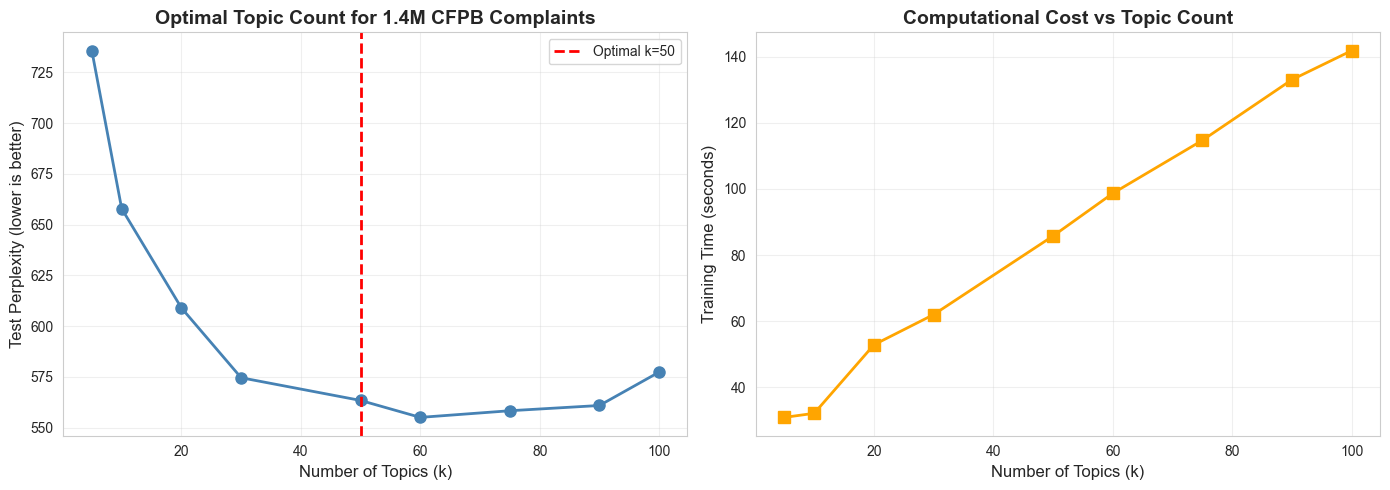


Saved: outputs/perplexity_optimal_topic_count.png


In [31]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Perplexity vs Topic Count
ax1.plot(df_results['k'], df_results['test_perplexity'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
ax1.axvline(optimal_k, color='red', linestyle='--', linewidth=2, 
            label=f'Optimal k={optimal_k}')
ax1.set_xlabel('Number of Topics (k)', fontsize=12)
ax1.set_ylabel('Test Perplexity (lower is better)', fontsize=12)
ax1.set_title('Optimal Topic Count for 1.4M CFPB Complaints', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Training Time vs Topic Count
ax2.plot(df_results['k'], df_results['train_time'], 
         marker='s', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Number of Topics (k)', fontsize=12)
ax2.set_ylabel('Training Time (seconds)', fontsize=12)
ax2.set_title('Computational Cost vs Topic Count', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/perplexity_optimal_topic_count.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: outputs/perplexity_optimal_topic_count.png")

---
## 7. TEST 2: Unigram vs Bigram (with Optimal k)

After obtaining the optimal number of topics, testing whether bigrams improve quality.

In [32]:
print("=" * 70)
print("TEST 2: UNIGRAM vs BIGRAM")
print("=" * 70)

print(f"\nUsing optimal k = {optimal_k} topics")
print(f"      Only need to train bigram model")

TEST 2: UNIGRAM vs BIGRAM

Using optimal k = 50 topics
      Only need to train bigram model


In [43]:
print("=" * 70)
print("TRAIN/TEST SPLIT FOR PERPLEXITY")
print("=" * 70)

print(f"\nFull dataset: {len(df_lda):,} complaints")
print(f"Split: 80% train, 20% test")
print(f"Random seed: 42")

train_texts, test_texts = train_test_split(
    df_lda['narrative_for_lda'],
    test_size=0.2,
    random_state=42
)

print(f"\nSplit complete:")
print(f"   Train: {len(train_texts):,} complaints")
print(f"   Test:  {len(test_texts):,} complaints")

TRAIN/TEST SPLIT FOR PERPLEXITY

Full dataset: 1,399,222 complaints
Split: 80% train, 20% test
Random seed: 42

Split complete:
   Train: 1,119,377 complaints
   Test:  279,845 complaints


In [44]:
# Build bigram vocabulary
print("\nBuilding bigram vocabulary...")

vectorizer_bigram = CountVectorizer(
    max_features=5000,  # Restricted to reduce noise
    min_df=20,
    max_df=0.9,
    ngram_range=(1, 2),  # Unigrams + Bigrams
    token_pattern=r'(?u)\b\w+\b',
    stop_words='english'
)

start = time.time()
train_bow_bi = vectorizer_bigram.fit_transform(train_texts)
test_bow_bi = vectorizer_bigram.transform(test_texts)
vocab_time_bi = time.time() - start

vocab_bi = vectorizer_bigram.get_feature_names_out()
bigrams = [w for w in vocab_bi if ' ' in w]

print(f"\nBigram vocabulary: {vocab_time_bi:.1f}s")
print(f"   Total terms: {len(vocab_bi):,}")
print(f"   Bigrams: {len(bigrams):,} ({len(bigrams)/len(vocab_bi)*100:.1f}%)")
print(f"   Matrix shape: {train_bow_bi.shape}")
print(f"\nExample bigrams:")
print(f"   {bigrams[:20]}")


Building bigram vocabulary...

Bigram vocabulary: 221.7s
   Total terms: 5,000
   Bigrams: 2,793 (55.9%)
   Matrix shape: (1119377, 5000)

Example bigrams:
   ['1666b creditor', '1666b late', '1666b requirements', '1666b time', '1681b code', '1681b permissible', '1681c block', '1681c consumer', '1681c credit', '1681c leads', '1681c section', '1681e 1681i', '1681e accuracy', '1681e failure', '1681e mandates', '1681e usc', '1681eb error', '1681i 1681g', '1681i credit', '1681i failure']


In [35]:
vocab

array(['000', '020', '1002', ..., 'zoom', 'zuntafi', 'zwicker'],
      shape=(16850,), dtype=object)

In [45]:
vocab_bi

array(['1028a', '15usc', '1666b', ..., 'zelle neglected',
       'zelle numerous', 'zero'], shape=(5000,), dtype=object)

In [37]:
df_uni_vocab = pd.DataFrame(vocab, columns=["values"])
df_uni_vocab.to_csv("data/vocab_uni.csv", index=False)

In [47]:
df_bi_vocab = pd.DataFrame(vocab_bi, columns=["values"])
df_bi_vocab.to_csv("data/vocab_bi_restricted.csv", index=False)

In [48]:
print("=" * 70)
print("TRAIN/TEST SPLIT FOR BIGRAM PERPLEXITY")
print("=" * 70)

print(f"\nSample dataset: {len(sample_df):,} complaints")
print(f"Split: 80% train, 20% test")
print(f"Random seed: 42")

train_texts, test_texts = train_test_split(
    sample_df['narrative_for_lda'],
    test_size=0.2,
    random_state=42
)
train_bow_bi = vectorizer_bigram.transform(train_texts)
test_bow_bi = vectorizer_bigram.transform(test_texts)

print(f"\nSplit complete:")
print(f"   Train: {len(train_texts):,} complaints")
print(f"   Test:  {len(test_texts):,} complaints")

TRAIN/TEST SPLIT FOR BIGRAM PERPLEXITY

Sample dataset: 100,000 complaints
Split: 80% train, 20% test
Random seed: 42

Split complete:
   Train: 80,000 complaints
   Test:  20,000 complaints


In [49]:
# Train bigram LDA with optimal k
print(f"\nTraining bigram LDA (k={optimal_k})...")

lda_bigram = LatentDirichletAllocation(
    n_components=optimal_k,
    max_iter=20,
    learning_method='online',
    learning_offset=50.0,
    batch_size=2048,  # Smaller than unigram (bigger matrix)
    evaluate_every=-1,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

start = time.time()
lda_bigram.fit(train_bow_bi)
train_time_bi = time.time() - start

train_perp_bi = lda_bigram.perplexity(train_bow_bi)
test_perp_bi = lda_bigram.perplexity(test_bow_bi)

print(f"\nTraining: {train_time_bi:.1f}s")
print(f"   Train perplexity: {train_perp_bi:.2f}")
print(f"   Test perplexity:  {test_perp_bi:.2f}")


Training bigram LDA (k=50)...

Training: 133.9s
   Train perplexity: 503.29
   Test perplexity:  535.85


In [53]:
# Get unigram results for comparison (from optimal_k)
unigram_result = [r for r in results_topic_count if r['k'] == optimal_k][0]
test_perp_uni = unigram_result['test_perplexity']
train_time_uni = unigram_result['train_time']

# Compare
print("=" * 70)
print("UNIGRAM vs BIGRAM COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': ['Unigram', 'Bigram'],
    'Topics (k)': [optimal_k, optimal_k],
    'Vocabulary': [len(vocab), len(vocab_bi)],
    'Bigrams': [0, len(bigrams)],
    'Train Time (s)': [f"{train_time_uni:.1f}", f"{train_time_bi:.1f}"],
    'Test Perplexity': [f"{test_perp_uni:.2f}", f"{test_perp_bi:.2f}"]
})

print("\n" + comparison.to_string(index=False))

improvement = test_perp_bi - test_perp_uni
improvement_pct = (improvement / test_perp_uni) * 100

print(f"\nAnalysis:")
if improvement > 0:
    print(f"   Bigram perplexity WORSE by {abs(improvement):.2f} ({abs(improvement_pct):.1f}%)")
    print(f"   WINNER: UNIGRAM")
    winner = 'unigram'
    loser = 'bigram'
else:
    print(f"   Bigram perplexity BETTER by {abs(improvement):.2f} ({abs(improvement_pct):.1f}%)")
    print(f"   WINNER: BIGRAM")
    winner = 'bigram'
    loser = 'unigram'

print(f"\nFinal Conclusion:")
print(f"   Using {winner.upper()} model with k={optimal_k} topics")

UNIGRAM vs BIGRAM COMPARISON

  Model  Topics (k)  Vocabulary  Bigrams Train Time (s) Test Perplexity
Unigram          50       16850        0           85.8          563.45
 Bigram          50        5000     2793          133.9          535.85

Analysis:
   Bigram perplexity BETTER by 27.61 (4.9%)
   WINNER: BIGRAM

Final Conclusion:
   Using BIGRAM model with k=50 topics


---
## 8. Inspect Topics from Winning Model

In [52]:
print("=" * 70)
print(f"TOP TOPICS FROM WINNING MODEL ({winner.upper()}, k={optimal_k})")
print("=" * 70)

if winner == 'unigram':
    # Get the LDA model for optimal_k from results
    # Re-train to get model object
    lda_final = LatentDirichletAllocation(
        n_components=optimal_k,
        max_iter=20,
        learning_method='online',
        batch_size=4096,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    lda_final.fit(train_bow)
    feature_names = vocab
else:
    lda_final = lda_bigram
    feature_names = vocab_bi

# Show top 20 topics
n_show = min(20, optimal_k)
print(f"\nShowing {n_show} of {optimal_k} topics:")

for i in range(n_show):
    top_idx = lda_final.components_[i].argsort()[-15:][::-1]
    top_words = [feature_names[idx] for idx in top_idx]
    
    # Separate codes from words
    codes = [w for w in top_words if re.search(r'\d', w)]
    words = [w for w in top_words if not re.search(r'\d', w)]
    
    print(f"\nTopic {i+1}:")
    print(f"  Words: {', '.join(words[:10])}")
    if codes:
        print(f"  Legal: {', '.join(codes[:5])}")

print(f"\nNote: Legal codes indicate which laws consumers are citing")
print(f"   15usc1681 = Fair Credit Reporting Act (FCRA)")
print(f"   15usc1692 = Fair Debt Collection Practices Act (FDCPA)")
print(f"   12cfr1005 = Regulation E (Electronic Funds)")

TOP TOPICS FROM WINNING MODEL (BIGRAM, k=50)

Showing 20 of 50 topics:

Topic 1:
  Words: report, soon, credit, soon possible, possible, credit report, reports, consumer reports, consumer, stuff

Topic 2:
  Words: fcra, reporting, credit, act, credit reporting, fair, fair credit, violation, reporting act, failure

Topic 3:
  Words: consumer, report, reporting, information, consumer report, code, consumer reporting, violation, credit, usc

Topic 4:
  Words: cash, app, cash app, unfair, act, resolution, financial, deceptive, unfair deceptive, practices

Topic 5:
  Words: experian, equifax, disputed, consumer, credit, failing, evidence, accounts, experian equifax, disputes

Topic 6:
  Words: accounts, credit, code, reporting, credit report, report, legal action, unjust, action, legal

Topic 7:
  Words: identity, theft, identity theft, report, fraudulent, information, credit, accounts, items, victim

Topic 8:
  Words: credit, acct, usc, reporting, credit card, act, card, reporting act, cre

## 8. Inspect Topics from Losing Model

In [54]:
print("=" * 70)
print(f"TOP TOPICS FROM LOSING MODEL ({loser.upper()}, k={optimal_k})")
print("=" * 70)

if loser == 'unigram':
    # Get the LDA model for optimal_k from results
    # Re-train to get model object
    lda_final = LatentDirichletAllocation(
        n_components=optimal_k,
        max_iter=20,
        learning_method='online',
        batch_size=4096,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    lda_final.fit(train_bow)
    feature_names = vocab
else:
    lda_final = lda_bigram
    feature_names = vocab_bi

# Show top 20 topics
n_show = min(20, optimal_k)
print(f"\nShowing {n_show} of {optimal_k} topics:")

for i in range(n_show):
    top_idx = lda_final.components_[i].argsort()[-15:][::-1]
    top_words = [feature_names[idx] for idx in top_idx]
    
    # Separate codes from words
    codes = [w for w in top_words if re.search(r'\d', w)]
    words = [w for w in top_words if not re.search(r'\d', w)]
    
    print(f"\nTopic {i+1}:")
    print(f"  Words: {', '.join(words[:10])}")
    if codes:
        print(f"  Legal: {', '.join(codes[:5])}")

print(f"\nNote: Legal codes indicate which laws consumers are citing")
print(f"   15usc1681 = Fair Credit Reporting Act (FCRA)")
print(f"   15usc1692 = Fair Debt Collection Practices Act (FDCPA)")
print(f"   12cfr1005 = Regulation E (Electronic Funds)")

TOP TOPICS FROM LOSING MODEL (UNIGRAM, k=50)

Showing 20 of 50 topics:

Topic 1:
  Words: abovementioned, arrogance, abra, deliquent, cloud, despite, attractive, discloses, bankruptcy, citicards
  Legal: 15usc1692

Topic 2:
  Words: appeared, disc, cleary, altogether, cheating, ent, extenuating, expedient, favors, anxxxx
  Legal: 4th, 1099b

Topic 3:
  Words: cleary, discloses, breath, favorite, bait, comfortable, disc, circumstance, attempted, disbursing
  Legal: 1692k, 168s

Topic 4:
  Words: cafe, cleary, assembled, cvv, advantage, dirty, court, dirt, disc, comprising
  Legal: 16821c, 192, 1974

Topic 5:
  Words: comxxxx, contrast, csr, concealing, exploits, culpable, cognizant, chains, aft, crest

Topic 6:
  Words: consolidation, blitt, cpfa, enriched, bait, ebt, allonge, deficiencies, demonstrated, constitutional

Topic 7:
  Words: faircreditreporting, brigit, fearful, annuities, aidvantage, compensates, alloted, breakdowns, comenityxxxx, dates

Topic 8:
  Words: development, cult

---
## 9. Save Results

In [55]:
print("=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save topic count experiment
with open('outputs/perplexity_topic_count_results.json', 'w') as f:
    json.dump(results_topic_count, f, indent=2)

print("\nSaved: outputs/perplexity_topic_count_results.json")

# Save final recommendation
final_config = {
    'optimal_k': optimal_k,
    'winner': winner,
    'vocabulary_size': len(vocab) if winner == 'unigram' else len(vocab_bi),
    'test_perplexity': test_perp_uni if winner == 'unigram' else test_perp_bi,
    'keep_legal_codes': True,
    'min_df': 20,
    'max_df': 0.5,
    'timestamp': datetime.now().isoformat()
}

with open('outputs/perplexity_final_config.json', 'w') as f:
    json.dump(final_config, f, indent=2)

print("Saved: outputs/perplexity_final_config.json")

print(f"\nFinal Configuration:")
for key, val in final_config.items():
    print(f"   {key}: {val}")

SAVING RESULTS

Saved: outputs/perplexity_topic_count_results.json
Saved: outputs/perplexity_final_config.json

Final Configuration:
   optimal_k: 50
   winner: bigram
   vocabulary_size: 5000
   test_perplexity: 535.8453672885174
   keep_legal_codes: True
   min_df: 20
   max_df: 0.5
   timestamp: 2026-03-04T22:34:55.329412


---
## 10. Summary

In [58]:
print("\n" + "=" * 70)
print("PERPLEXITY EVALUATION COMPLETE")
print("=" * 70)

print(f"\nKey Findings:")
print(f"   Dataset: {len(sample_df):,} CFPB complaints")
print(f"   Optimal topics (k): {optimal_k}")
print(f"   Best model: {winner.upper()}")
print(f"   Test perplexity: {test_perp_uni if winner == 'unigram' else test_perp_bi:.2f}")
print(f"   Vocabulary: {len(vocab) if winner == 'unigram' else len(vocab_bi):,} terms")

print(f"\n Conclusion for Final Pipeline:")
print(f"   Use {winner} LDA")
print(f"   Use k={optimal_k} topics (not 5!)")
print(f"   Vocabulary size: 5,000 terms")
print(f"   min_df=20, max_df=0.9")

print(f"\nOutput files:")
print(f"   outputs/perplexity_optimal_topic_count.png")
print(f"   outputs/perplexity_topic_count_results.json")
print(f"   outputs/perplexity_final_config.json")


PERPLEXITY EVALUATION COMPLETE

Key Findings:
   Dataset: 100,000 CFPB complaints
   Optimal topics (k): 50
   Best model: BIGRAM
   Test perplexity: 535.85
   Vocabulary: 5,000 terms

 Conclusion for Final Pipeline:
   Use bigram LDA
   Use k=50 topics (not 5!)
   Vocabulary size: 5,000 terms
   min_df=20, max_df=0.9

Output files:
   outputs/perplexity_optimal_topic_count.png
   outputs/perplexity_topic_count_results.json
   outputs/perplexity_final_config.json


In [59]:
df_lda.tail()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,narrative_cleaned,narrative_for_lda
1399217,04/20/24,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am looking to have all items deleted to help...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33312,NaN,Consent provided,Web,04/20/24,Closed with non-monetary relief,Yes,NaN,8820325,i am looking to have all items deleted to help...,looking items deleted help clear credit report...,0.6597,0.088,0.674,0.237,1.0,0.0,0.0,184,34,looking items deleted help clear credit report...,looking have all items deleted help clear cred...
1399218,12/18/23,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the Fair Credit Reporting a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,78640,NaN,Consent provided,Web,12/18/23,Closed with non-monetary relief,Yes,NaN,8021911,in accordance with the fair credit reporting a...,accordance fair credit reporting act list acco...,-0.5719,0.049,0.918,0.033,0.0,0.0,0.4,1231,223,accordance fair credit reporting act list acco...,accordance with the fair credit reporting act....
1399219,03/06/24,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,I am listing accounts below that have been rep...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,TX,75217,NaN,Consent provided,Web,03/06/24,Closed with explanation,Yes,NaN,8485349,i am listing accounts below that have been rep...,listing accounts reported inaccurately credit ...,0.9601,0.098,0.656,0.247,1.0,0.0,0.0,710,117,listing accounts reported inaccurately credit ...,listing accounts below that have been reported...
1399220,11/01/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Subject : Request for Validation of Debt - XXX...,NaN,Experian Information Solutions Inc.,MI,48124,NaN,Consent provided,Web,11/01/24,Closed with explanation,Yes,NaN,10655394,subject : request for validation of debt - xxx...,subject request validation debt xxxx xxxx xxxx...,-0.9784,0.105,0.818,0.077,0.8,0.0,0.0,4169,729,subject request validation debt writing respon...,subject : request for validation debt - writin...
1399221,09/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I discovered incorrect accounts on my credit r...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85364,NaN,Consent provided,Web,09/08/25,Closed with non-monetary relief,Yes,NaN,15803635,i discovered incorrect accounts on my credit r...,discovered incorrect accounts credit report no...,-0.5173,0.107,0.829,0.064,1.0,0.0,0.0,403,69,discovered incorrect accounts credit report id...,"discovered incorrect accounts credit report, a..."
